# Chapter 6. Which checks must pass before the collected number leaves the team, and what does Anand get when one fails at the end of reporting day?

**Week 2, Tuesday · Chapter 6 of 6 · Booked against collected.**

> **The client asks.** "Booked revenue is not collected revenue. Some orders are paid in two
> instalments, some are refunded, some were never paid at all. Show me, order by order, what we
> actually collected against what we booked in Q2. If there is a gap, I want to know which orders
> and which channel."
>
> Anand Iyer, finance controller, Kalpa Retail

The data platform lead added the payments table to the team's access and said, in passing, that
the payments feed "sometimes double-posts when the gateway retries".

**Who needs the answer.** Kavya Nair, the team's senior analyst, reviews every number before it leaves the team, Anand forwards it to the CEO's Monday page, and you sign it. A validation that cannot fail puts a PASS stamp on a wrong number, and a stamped wrong number is harder to withdraw than an unstamped one.

**The questions on the way.**
1. Do the checks a hurried analyst writes pass a report that hides an unpaid order?
2. Which checks tie the report back to the two tables?
3. Do the two suites stop every wrong report the day has met?
4. Does the tie-back suite pass Kalpa's Q2 report?
5. Does a second tool, working from the raw rows, reach the same numbers?
6. What does Anand get when a check fails at the end of reporting day?

**The metric at stake.** At stake are the collected figure and its gap, every Monday, and the checks that stand between them and Anand, each measured by which of the day's wrong reports it would stop.

**What came before, and what this adds.** Chapter 5 built the page Anand signs: one line per channel, with orders, booked, collected and a gap that uses `coalesce(collected, 0)`, so an unpaid order counts as nothing paid. On the invented tables app's gap is 800, T-4; on Kalpa's Q2 you built the page and it added back to the bridge. Over the day five wrong pages appeared, each plausible: chapter 2's fan-out draft, chapter 3's plain JOIN draft and its LEFT JOIN that still read posted as collected, chapter 4's quarter in WHERE, and chapter 5's gap added up order by order. This chapter builds the checks that stop all five, every Monday, before the number leaves.

**Setup.** The next cell finds the helper, connects to the warehouse, creates the invented tables of
chapter 1, and writes on them the day's five wrong pages, each with the mistake its chapter staged.
Every query below is also in `sql/C2_W02_D02_06_can_it_leave_STUDENT.sql`.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
from decimal import Decimal

TINY = """DROP TABLE IF EXISTS pg_temp.tiny_orders, pg_temp.tiny_payments;
CREATE TEMP TABLE tiny_orders (
    order_id  text PRIMARY KEY,
    channel   text NOT NULL,
    amount    numeric(12, 2) NOT NULL
);
CREATE TEMP TABLE tiny_payments (
    payment_id    text PRIMARY KEY,
    order_id      text NOT NULL,
    paid_date     date NOT NULL,
    amount        numeric(12, 2) NOT NULL,
    instalment_no integer NOT NULL
);
INSERT INTO tiny_orders VALUES
    ('T-1', 'app',   1000),
    ('T-2', 'web',   2000),
    ('T-3', 'store', 1500),
    ('T-4', 'app',    800),
    ('T-5', 'store',  500);
INSERT INTO tiny_payments VALUES
    ('P-1', 'T-1', '2026-07-03', 1000, 1),
    ('P-2', 'T-2', '2026-07-05', 1200, 1),
    ('P-3', 'T-2', '2026-08-05',  800, 2),
    ('P-4', 'T-3', '2026-07-09', 1500, 1),
    ('P-5', 'T-3', '2026-07-09', 1500, 1),
    ('P-6', 'T-5', '2026-07-12',  500, 1),
    ('P-7', 'T-9', '2026-07-14',  600, 1);"""

conn = kit.connect()
conn.autocommit = True
with conn.cursor() as cur:
    cur.execute(TINY)            # invented, TEMP, so they vanish when this notebook stops


def run(query, params=None):
    """Run a query on this notebook's one connection and return its rows as dictionaries."""
    return kit.sql(query, params, conn=conn)


def one(query, params=None):
    """The first value of the first row, for a query that returns a single number."""
    row = run(query, params)[0]
    return next(iter(row.values()))


def show(rows, caption="", money=()):
    """Rows as the kit's table; columns named in money print as rupees."""
    if not rows:
        return kit.table(["result"], [["no rows"]], caption)
    heads = list(rows[0])
    body = []
    for r in rows:
        line = []
        for h in heads:
            v = r[h]
            if v is None:
                line.append("NULL")
            elif h in money:
                line.append(kit.rupees(v))
            elif isinstance(v, Decimal):
                line.append(f"{int(v):,}" if v == v.to_integral_value() else f"{float(v):,.2f}")
            else:
                line.append(str(v))
        body.append(line)
    kit.table(heads, body, caption)

PLAUSIBLE = [
    ("collected is at most booked", lambda r, s: r["collected"] <= r["booked"]),
    ("the gap is not negative", lambda r, s: r["gap"] is not None and r["gap"] >= 0),
    ("all three channels are on it", lambda r, s: set(r["channels"]) >= {"app", "store", "web"}),
]
TIE_BACK = [
    ("orders on the report equal orders in the table", lambda r, s: r["orders"] == s["orders"]),
    ("booked equals booked from orders alone", lambda r, s: r["booked"] == s["booked"]),
    ("the gap equals booked less collected", lambda r, s: r["gap"] == r["booked"] - r["collected"]),
    ("the gap equals the never-paid and paid-short lists",
     lambda r, s: r["gap"] == (s["never_paid"] or 0) + (s["paid_short"] or 0)),
    ("collected plus posted twice equals posted from payments alone",
     lambda r, s: r["collected"] + (s["posted_twice"] or 0) == s["posted"]),
]


def validate(report, source, suite):
    """Every check in the suite, run on one report against the single-table sources."""
    return [(name, bool(test(report, source))) for name, test in suite]

with conn.cursor() as cur:
    cur.execute("""
CREATE TEMP VIEW tiny_per_order AS
WITH per_instalment AS (
    SELECT order_id, instalment_no, max(amount) AS amount
    FROM tiny_payments
    GROUP BY order_id, instalment_no
),
collected_per_order AS (
    SELECT order_id, sum(amount) AS collected
    FROM per_instalment
    GROUP BY order_id
),
posted_per_order AS (
    SELECT order_id, sum(amount) AS posted
    FROM tiny_payments
    GROUP BY order_id
)
SELECT o.order_id, o.channel, o.amount AS booked, c.collected, p.posted
FROM tiny_orders o
LEFT JOIN collected_per_order c ON c.order_id = o.order_id
LEFT JOIN posted_per_order p    ON p.order_id = o.order_id;
CREATE TEMP VIEW q2_per_order AS
WITH per_instalment AS (
    SELECT order_id, instalment_no, max(amount) AS amount
    FROM payments
    GROUP BY order_id, instalment_no
),
collected_per_order AS (
    SELECT order_id, sum(amount) AS collected
    FROM per_instalment
    GROUP BY order_id
),
posted_per_order AS (
    SELECT order_id, sum(amount) AS posted
    FROM payments
    GROUP BY order_id
)
SELECT o.order_id, o.channel, o.amount AS booked, c.collected, p.posted
FROM orders o
LEFT JOIN collected_per_order c ON c.order_id = o.order_id
LEFT JOIN posted_per_order p    ON p.order_id = o.order_id
WHERE o.quarter = 'Q2';""")   # chapter 3's per-order table, as TEMP views

WRONG = {}
WRONG['fan-out draft'] = """SELECT count(*) AS orders,
       (SELECT sum(amount) FROM tiny_orders) AS booked,
       sum(o.amount) FILTER (WHERE p.payment_id IS NOT NULL) AS collected,
       (SELECT sum(amount) FROM tiny_orders)
           - sum(o.amount) FILTER (WHERE p.payment_id IS NOT NULL) AS gap,
       array_agg(DISTINCT o.channel) AS channels
FROM tiny_orders o
LEFT JOIN tiny_payments p ON p.order_id = o.order_id"""
WRONG['plain JOIN draft'] = """WITH posted_per_order AS (
    SELECT order_id, sum(amount) AS posted
    FROM tiny_payments
    GROUP BY order_id
)
SELECT count(*) AS orders, sum(o.amount) AS booked, sum(pp.posted) AS collected,
       sum(o.amount) - sum(pp.posted) AS gap, array_agg(DISTINCT o.channel) AS channels
FROM tiny_orders o
JOIN posted_per_order pp ON pp.order_id = o.order_id"""
WRONG['posted as collected'] = """WITH posted_per_order AS (
    SELECT order_id, sum(amount) AS posted
    FROM tiny_payments
    GROUP BY order_id
)
SELECT count(*) AS orders, sum(o.amount) AS booked, sum(pp.posted) AS collected,
       sum(o.amount) - sum(pp.posted) AS gap, array_agg(DISTINCT o.channel) AS channels
FROM tiny_orders o
LEFT JOIN posted_per_order pp ON pp.order_id = o.order_id"""
WRONG['quarter in WHERE'] = """WITH per_order AS (
    SELECT o.order_id, o.channel, o.amount AS booked, sum(i.amount) AS collected
    FROM tiny_orders o
    LEFT JOIN (SELECT order_id, instalment_no, max(amount) AS amount, max(paid_date) AS paid_date
               FROM tiny_payments
               GROUP BY order_id, instalment_no) i ON i.order_id = o.order_id
    WHERE i.paid_date BETWEEN '2026-07-01' AND '2026-09-30'
    GROUP BY o.order_id, o.channel, o.amount
)
SELECT count(*) AS orders, sum(booked) AS booked, sum(collected) AS collected,
       sum(booked) - sum(collected) AS gap, array_agg(DISTINCT channel) AS channels
FROM per_order"""
WRONG['gap summed per order'] = """SELECT count(*) AS orders, sum(booked) AS booked, sum(collected) AS collected,
       sum(booked - collected) AS gap, array_agg(DISTINCT channel) AS channels
FROM tiny_per_order"""
WRONG['true report'] = """SELECT count(*) AS orders, sum(booked) AS booked, sum(coalesce(collected, 0)) AS collected,
       sum(booked - coalesce(collected, 0)) AS gap, array_agg(DISTINCT channel) AS channels
FROM tiny_per_order"""

reports = {name: run(q)[0] for name, q in WRONG.items()}
src_tiny = run("""SELECT (SELECT count(*) FROM tiny_orders o)                           AS orders,
       (SELECT sum(amount) FROM tiny_orders o)                        AS booked,
       (SELECT sum(amount) FROM tiny_payments
         WHERE order_id IN (SELECT order_id FROM tiny_orders o))      AS posted,
       (SELECT sum(amount) FROM tiny_orders o WHERE
            NOT EXISTS (SELECT 1 FROM tiny_payments p
                        WHERE p.order_id = o.order_id))                   AS never_paid,
       (SELECT sum(o.amount - c.collected)
          FROM tiny_orders o
          JOIN (SELECT order_id, sum(amount) AS collected
                  FROM (SELECT order_id, instalment_no, max(amount) AS amount
                          FROM tiny_payments
                         GROUP BY order_id, instalment_no) AS once
                 GROUP BY order_id) AS c ON c.order_id = o.order_id
         WHERE c.collected < o.amount)                              AS paid_short,
       (SELECT sum(extra)
          FROM (SELECT sum(p.amount) - max(p.amount) AS extra
                FROM tiny_payments p JOIN tiny_orders o ON o.order_id = p.order_id
                GROUP BY p.order_id, p.instalment_no) AS repeats)         AS posted_twice""")[0]
print("Written on the invented tables:", ", ".join(reports), sep="\n  ")

Written on the invented tables:
  fan-out draft, plain JOIN draft, posted as collected, quarter in WHERE, gap summed per order, true report


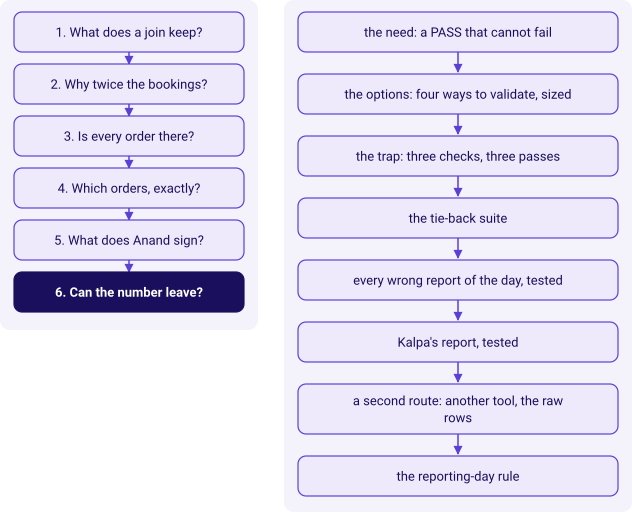

In [2]:
kit.side_by_side(
    kit.ladder(['What does a join keep?', 'Why twice the bookings?', 'Is every order there?', 'Which orders, exactly?', 'What does Anand sign?', 'Can the number leave?'], lit=5, show=False),
    kit.vflow(['the need: a PASS that cannot fail', 'the options: four ways to validate, sized', 'the trap: three checks, three passes', 'the tie-back suite', 'every wrong report of the day, tested', "Kalpa's report, tested", 'a second route: another tool, the raw rows', 'the reporting-day rule'], show=False),
)

## What does a PASS stamp cost when the check behind it could not fail?

The Monday number is refreshed every week, by whoever is on the rota, sometimes late on reporting
day. Checks let a number leave without Kavya reading every query. A check is useful only if it can
fail, and a suite that passes a wrong report does worse than no suite, because the PASS line travels
with the number and Anand forwards it with more confidence than he would forward an
unchecked one. The retail story behind Anand's role, how a sale becomes cash and who checks it, is in the domain dossier, `content/W01/D1/study-notes/C2_W01_D01_domain_retail_STUDENT.md`, sections 3 and 4.

**Who else faces this.** Wirecard, a German payments company, collapsed in June 2020 over cash it
reported and did not have. On 18 June its auditor, EY, refused to sign off on the accounts, saying it
was unable to confirm that the money existed; on 22 June Wirecard said there was "a prevailing likelihood"
that 1.9 billion euros of trust account balances did not exist; on 25 June it filed for insolvency
(BBC News, 18, 22 and 25 June 2020, checked 1 Oct 2026). People with first-hand knowledge told the
Financial Times that from 2016 to 2018 the auditor had not checked directly with Singapore's OCBC
Bank, where Wirecard claimed it had up to 1 billion euros in cash, and relied instead on documents
and screenshots from a third-party trustee and from Wirecard itself (FT, republished by the Irish
Times, 26 June 2020, checked 1 Oct 2026).

**The two invented tables.** They hold five orders and seven payments, invented to carry every
case Anand named and the one the platform lead mentioned, so every row can be checked by hand:

| order_id | channel | amount | What happened to it |
|---|---|---|---|
| T-1 | app | 1,000 | Paid once, in full (P-1) |
| T-2 | web | 2,000 | Paid in two instalments, 1,200 and 800 (P-2, P-3) |
| T-3 | store | 1,500 | Paid once, and the gateway posted that payment twice (P-4, P-5) |
| T-4 | app | 800 | Never paid |
| T-5 | store | 500 | Paid once, in full (P-6) |

P-7 is a payment of 600 against T-9, an order that is not in the orders table.

**The day's five wrong pages.** Each is one of the day's mistakes, written on the invented tables into
a page of orders, booked, collected and gap. The true page from chapter 5 sits last. Every page
carries all three channels.

In [3]:
ORIGIN = {'fan-out draft': 'Chapter 2: the order amount summed on every payment row', 'plain JOIN draft': 'Chapter 3: an INNER JOIN, posted read as collected', 'posted as collected': 'Chapter 3: the join fixed to LEFT, posted still read as collected', 'quarter in WHERE': "Chapter 4: the quarter's dates on payments, placed in WHERE", 'gap summed per order': "Chapter 5: each order's gap added up, T-4's NULL skipped", 'true report': 'Chapter 5: the page Anand signs'}
kit.table(["Page", "Where the day met it", "Orders", "Booked", "Collected", "Gap"],
          [(name, ORIGIN[name], r["orders"], f'{int(r["booked"]):,}', f'{int(r["collected"]):,}',
            f'{int(r["gap"]):,}') for name, r in reports.items()],
          caption="Invented: the day's five wrong pages and the true one")

Page,Where the day met it,Orders,Booked,Collected,Gap
fan-out draft,Chapter 2: the order amount summed on every payment row,7,"5,800","8,500","-2,700"
plain JOIN draft,"Chapter 3: an INNER JOIN, posted read as collected",4,"5,000","6,500","-1,500"
posted as collected,"Chapter 3: the join fixed to LEFT, posted still read as collected",5,"5,800","6,500",-700
quarter in WHERE,"Chapter 4: the quarter's dates on payments, placed in WHERE",4,"5,000","5,000",0
gap summed per order,"Chapter 5: each order's gap added up, T-4's NULL skipped",5,"5,800","5,000",0
true report,Chapter 5: the page Anand signs,5,"5,800","5,000",800


## Which of four ways to validate stops the day's wrong reports, and what does each cost?

| Option | What it does | What it needs |
|---|---|---|
| A. Read the report before sending it | A person looks at the page | Someone who knows the numbers, every Monday |
| B. Plausibility checks | Collected at most booked, no negative gap, every channel present | Only the report itself |
| C. Tie-back checks | Every figure on the report recomputed from the source tables and compared | The two source tables |
| D. An independent recomputation | The same figures from the raw rows by another tool, or from the gateway's settlement file | A second method, or a second source |

The cell below runs B, C and D against the five wrong reports rebuilt above, counts how many each
stops, and times each on Kalpa's Q2. A is not sized, since what it catches depends on who reads.

Option,"Wrong reports it stops, of 5",Time on Kalpa's Q2
A. read it,depends on the reader,minutes of a person
B. plausibility,3,"3 ms, the report alone"
C. tie-back,5,"7 ms, report and sources"
D. recompute in Python,5,"4 ms, the raw rows"


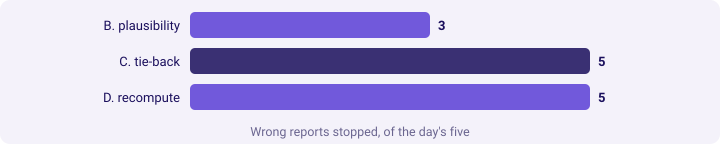

In [4]:
import time


def recompute_in_python(orders_rows, payment_rows):
    """Orders, booked, collected and the gap from the raw rows, with no join: Week 1's accumulator."""
    booked = {o["order_id"]: o["amount"] for o in orders_rows}
    once = {}
    for p in payment_rows:                      # a repeat of one instalment overwrites, so it counts once
        if p["order_id"] in booked:
            once[(p["order_id"], p["instalment_no"])] = p["amount"]
    collected = sum(once.values())
    return {"orders": len(booked), "booked": sum(booked.values()), "collected": collected,
            "gap": sum(booked.values()) - collected}


py_tiny = recompute_in_python(run("SELECT order_id, channel, amount FROM tiny_orders"),
                              run("SELECT order_id, instalment_no, amount FROM tiny_payments"))
wrong_names = [k for k in reports if k != "true report"]
stops = {"B. plausibility": 0, "C. tie-back": 0, "D. recompute": 0}
for name in wrong_names:
    r = reports[name]
    stops["B. plausibility"] += not all(ok for _, ok in validate(r, src_tiny, PLAUSIBLE))
    stops["C. tie-back"] += not all(ok for _, ok in validate(r, src_tiny, TIE_BACK))
    stops["D. recompute"] += any(r[k] != py_tiny[k] for k in ("orders", "booked", "collected", "gap"))
t0 = time.perf_counter(); rep_k = run("""SELECT count(*) AS orders, sum(booked) AS booked, sum(coalesce(collected, 0)) AS collected,
       sum(booked - coalesce(collected, 0)) AS gap, array_agg(DISTINCT channel) AS channels
FROM q2_per_order""")[0]; t_report = time.perf_counter() - t0
t0 = time.perf_counter(); src_k = run("""SELECT (SELECT count(*) FROM orders o WHERE o.quarter = 'Q2')                           AS orders,
       (SELECT sum(amount) FROM orders o WHERE o.quarter = 'Q2')                        AS booked,
       (SELECT sum(amount) FROM payments
         WHERE order_id IN (SELECT order_id FROM orders o WHERE o.quarter = 'Q2'))      AS posted,
       (SELECT sum(amount) FROM orders o WHERE o.quarter = 'Q2' AND
            NOT EXISTS (SELECT 1 FROM payments p
                        WHERE p.order_id = o.order_id))                   AS never_paid,
       (SELECT sum(o.amount - c.collected)
          FROM orders o
          JOIN (SELECT order_id, sum(amount) AS collected
                  FROM (SELECT order_id, instalment_no, max(amount) AS amount
                          FROM payments
                         GROUP BY order_id, instalment_no) AS once
                 GROUP BY order_id) AS c ON c.order_id = o.order_id
         WHERE o.quarter = 'Q2' AND c.collected < o.amount)                              AS paid_short,
       (SELECT sum(extra)
          FROM (SELECT sum(p.amount) - max(p.amount) AS extra
                FROM payments p JOIN orders o ON o.order_id = p.order_id WHERE o.quarter = 'Q2'
                GROUP BY p.order_id, p.instalment_no) AS repeats)         AS posted_twice""")[0]; t_src = time.perf_counter() - t0
t0 = time.perf_counter()
py_k = recompute_in_python(run("SELECT order_id, channel, amount FROM orders WHERE quarter = 'Q2'"),
                           run("SELECT order_id, instalment_no, amount FROM payments"))
t_py = time.perf_counter() - t0
kit.table(["Option", "Wrong reports it stops, of 5", "Time on Kalpa's Q2"],
          [("A. read it", "depends on the reader", "minutes of a person"),
           ("B. plausibility", stops["B. plausibility"], f"{t_report * 1000:.0f} ms, the report alone"),
           ("C. tie-back", stops["C. tie-back"], f"{(t_report + t_src) * 1000:.0f} ms, report and sources"),
           ("D. recompute in Python", stops["D. recompute"], f"{t_py * 1000:.0f} ms, the raw rows")],
          caption="Four ways to validate, sized on the day's five wrong reports and on Kalpa's Q2")
kit.bars([(k, v) for k, v in stops.items()], lit=[1], title="Wrong reports stopped, of the day's five")
kit.check("the tie-back suite stops all five wrong reports", stops["C. tie-back"] == 5, f'{stops["C. tie-back"]} of 5')

**The best-fit call.** Option C, the tie-back suite, fits best, with D beside it. The tie-back
suite stops all five of the day's wrong reports and runs in milliseconds, because each check compares a figure on the report
with the same figure computed outside it: booked from orders alone, posted from payments alone, and
the gap from lists no join can multiply.
The Python recomputation reaches the numbers by a different tool and a different rule for counting a
payment once, so an error in the SQL and the same error in the checks would still be caught.
Plausibility checks cost the same and stop three of the five.

**The fact that would change the call.** A settlement file from the gateway, the list of what
reached Kalpa's bank, would be a source outside Kalpa's own tables, and reconciling to it
would become the strongest check of all; until the platform lead supplies one, every check here
reads Kalpa's own records.

## 1. Do the checks a hurried analyst writes pass a report that hides an unpaid order?

**The plausible wrong answer.** A hurried validation checks what a finance reader expects to be true
of any collections report: collected is at most booked, the gap is not negative, and all three
channels are on the page. It runs on the page written with chapter 4's mistake, the quarter's dates
on payments placed in WHERE, which dropped T-4.

**Predict before you run.** How many of the three checks pass? a) none; b) one; c) two; d) all three.

Plausibility check,On the quarter-in-WHERE page
collected is at most booked,PASS
the gap is not negative,PASS
all three channels are on it,PASS


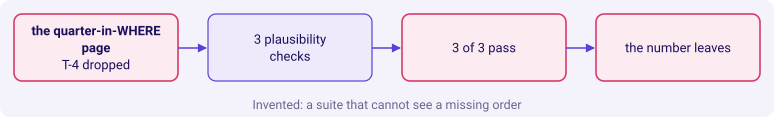

In [5]:
hidden = reports["quarter in WHERE"]
verdicts = validate(hidden, src_tiny, PLAUSIBLE)
kit.table(["Plausibility check", "On the quarter-in-WHERE page"], [(n_, "PASS" if ok else "FAIL") for n_, ok in verdicts],
          caption=f'Invented: a page of {hidden["orders"]} orders, booked {int(hidden["booked"]):,}, gap {int(hidden["gap"]):,}')
kit.flow(["the quarter-in-WHERE page\nT-4 dropped", "3 plausibility checks", "3 of 3 pass", "the number leaves"],
         kinds=["bad", "plain", "bad", "bad"], title="Invented: a suite that cannot see a missing order")
kit.check("the plausibility suite passes the report that hides T-4", all(ok for _, ok in verdicts), "3 of 3")

**What happened.** The answer is d: all three pass. The page shows 4 orders, booked 5,000, collected
5,000 and a gap of 0, and every one of those agrees with the others.

**Why it is wrong.** Each check tests the report against itself. The missing order took its booked
amount with it, so collected is still at most booked, the gap is still not negative, and T-4's
channel, app, is still on the page through T-1. A suite that never looks outside the report cannot
see what the report left out, and it stamps "3 of 3 passed" on a page that hides the one order
nobody paid.

## 2. Which checks tie the report back to the two tables?

Each tie-back check recomputes one figure outside the report and compares it with the report:

| Check | Computed from | Catches |
|---|---|---|
| Orders on the report equal orders in the table | `orders` alone | A dropped or repeated order |
| Booked equals booked from orders alone | `orders` alone | A fan-out that reached booked, a dropped order |
| The gap equals booked less collected | The report's own columns | A NULL that fell out of a sum |
| The gap equals the never-paid and paid-short lists | The anti-join, and each order's instalments against its booked | A dropped order, a NULL gap, a wrong list |
| Collected plus posted twice equals posted from payments alone | `payments` alone | A retry inside collected, a fan-out |

**Predict before you run.** On the same page, which checks fail? a) none; b) orders, booked and the
two lists; c) only the gap; d) all five.

In [6]:
tie = validate(hidden, src_tiny, TIE_BACK)
kit.table(["Tie-back check", "On the quarter-in-WHERE page"], [(n_, "PASS" if ok else "FAIL") for n_, ok in tie],
          caption="Invented: the same page, checked against the two tables")
kit.check("the tie-back suite fails the quarter-in-WHERE page on orders, booked and the two lists",
          [ok for _, ok in tie] == [False, False, True, False, True], "3 checks fail")

Tie-back check,On the quarter-in-WHERE page
orders on the report equal orders in the table,FAIL
booked equals booked from orders alone,FAIL
the gap equals booked less collected,PASS
the gap equals the never-paid and paid-short lists,FAIL
collected plus posted twice equals posted from payments alone,PASS


**What happened.** The answer is b: orders (4 against 5), booked (5,000 against 5,800) and the two
lists (a gap of 0 against 800 never paid and nothing paid short) all fail, while the page's own
arithmetic and its collected figure pass. The page agrees with itself and disagrees with the tables,
and only a check that looks outside it can say so.

## 3. Do the two suites stop every wrong report the day has met?

**Predict before you run.** The plausibility suite stops three of the day's five wrong pages. Which
two does it let through? a) the fan-out and plain JOIN drafts; b) the quarter in WHERE and the summed
gap; c) posted as collected and the quarter in WHERE; d) the fan-out draft and the summed gap.

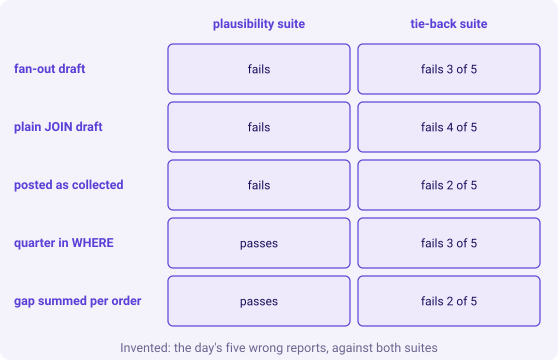

In [7]:
grid, rows = [], []
for name in wrong_names:
    p_ok = all(ok for _, ok in validate(reports[name], src_tiny, PLAUSIBLE))
    t_fail = [n_ for n_, ok in validate(reports[name], src_tiny, TIE_BACK) if not ok]
    grid.append(["passes" if p_ok else "fails", f"fails {len(t_fail)} of 5"])
    rows.append(name)
kit.matrix(rows, ["plausibility suite", "tie-back suite"], grid,
           title="Invented: the day's five wrong reports, against both suites")
through = [name for name, g in zip(rows, grid) if g[0] == "passes"]
kit.check("the plausibility suite lets through only the two wrong pages that hide T-4",
          sorted(through) == ["gap summed per order", "quarter in WHERE"], f"{len(through)} of 5")
kit.check("the tie-back suite fails every wrong report on at least one check",
          all(g[1] != "fails 0 of 5" for g in grid), "5 of 5 stopped")
kit.check("the tie-back suite passes the true report",
          all(ok for _, ok in validate(reports["true report"], src_tiny, TIE_BACK)), "5 of 5 pass")

**What happened.** The answer is b: the plausibility suite lets through the quarter in WHERE and the
gap summed per order, the two pages that hide T-4. It stops the other three because each puts more
cash on the page than was booked: the fan-out draft's 8,500 against 5,800, and posted read as
collected, 6,500 against 5,000 in the plain JOIN draft and against 5,800 after the LEFT JOIN. A page
that hides an order lowers its figures together, or loses the gap to a NULL, so nothing on it looks
wrong. The tie-back suite fails every wrong page on at least one check, the fan-out draft on orders,
the two lists and posted, and passes the true page on all five.

## 4. Does the tie-back suite pass Kalpa's Q2 report?

The same suite runs on Kalpa's Q2 page from chapter 5. The verdicts print; the figures that would
name what the room is finding stay unprinted.

"Tie-back check, Kalpa's Q2",Verdict,Detail
orders on the report equal orders in the table,PASS,462 against 462
booked equals booked from orders alone,PASS,"Rs 9,84,00,000 against Rs 9,84,00,000"
the gap equals booked less collected,PASS,"equal, unprinted"
the gap equals the never-paid and paid-short lists,PASS,"equal, unprinted"
collected plus posted twice equals posted from payments alone,PASS,"equal, unprinted"


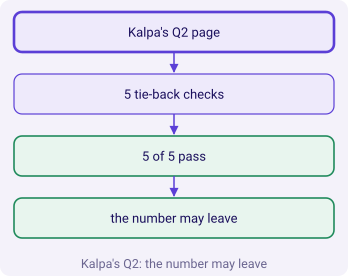

In [8]:
tie_k = validate(rep_k, src_k, TIE_BACK)
detail = {
    "orders on the report equal orders in the table": f'{rep_k["orders"]} against {src_k["orders"]}',
    "booked equals booked from orders alone": f'{kit.rupees(rep_k["booked"])} against {kit.rupees(src_k["booked"])}',
}
kit.table(["Tie-back check, Kalpa's Q2", "Verdict", "Detail"],
          [(n_, "PASS" if ok else "FAIL", detail.get(n_, "equal, unprinted")) for n_, ok in tie_k],
          caption="The suite on Kalpa's Q2 report")
kit.vflow(["Kalpa's Q2 page", "5 tie-back checks", "5 of 5 pass", "the number may leave"],
          kinds=["known", "plain", "good", "good"], title="Kalpa's Q2: the number may leave")
kit.check("every tie-back check passes on Kalpa's Q2 report", all(ok for _, ok in tie_k), "5 of 5")
homes = run("""SELECT coalesce(o.quarter, 'no order') AS home, count(*) AS n FROM payments p
                 LEFT JOIN orders o ON o.order_id = p.order_id GROUP BY 1""")
kit.check("every payment row sits on a Q1 order, a Q2 order or no order, and they add to the table",
          sum(h["n"] for h in homes) == one("SELECT count(*) FROM payments"), "1,428 rows, split unprinted")

**What happened.** Every check passes on Kalpa's Q2 report: 462 orders against 462, booked
Rs 9,84,00,000 against Rs 9,84,00,000, the gap equal to the never-paid and paid-short lists, and the
retries equal to posted less collected. This report may leave the team.

> **Kavya's review.** "A check that cannot fail is decoration. For every check, tell me which wrong
> report it would have stopped, and do not send me a PASS you have never seen fail."

## Does a second tool, working from the raw rows, reach the same numbers?

The second route leaves SQL's joins behind. Two plain SELECTs fetch the raw rows, one table each, and
Python counts them with Week 1's accumulator: booked per order from `orders`, and each order's
instalments from `payments`, keyed by order and instalment so that a repeat of the same instalment
overwrites itself and counts once. It shares no join, no GROUP BY and no NULL rule with the SQL
report, so a mistake in one is unlikely to repeat in the other.

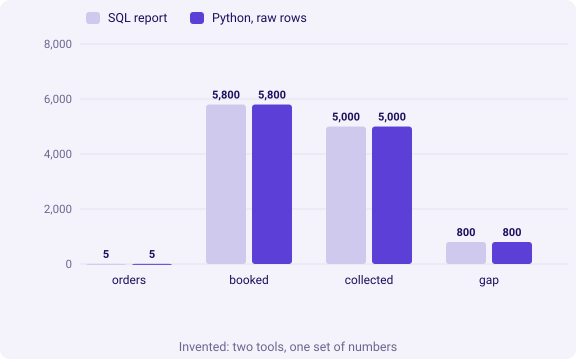

In [9]:
true_tiny = reports["true report"]
kit.columns(["orders", "booked", "collected", "gap"],
            [("SQL report", [float(true_tiny[k]) for k in ("orders", "booked", "collected", "gap")]),
             ("Python, raw rows", [float(py_tiny[k]) for k in ("orders", "booked", "collected", "gap")])],
            fmt=lambda v: f"{v:,.0f}", title="Invented: two tools, one set of numbers")
kit.check("invented: Python from the raw rows matches the SQL report on all four figures",
          all(true_tiny[k] == py_tiny[k] for k in ("orders", "booked", "collected", "gap")), "5 orders, 5,800, 5,000, 800")
kit.check("Kalpa's Q2: Python from the raw rows matches the SQL report on all four figures",
          all(rep_k[k] == py_k[k] for k in ("orders", "booked", "collected", "gap")), "equal, unprinted")

**What happened.** The two tools agree on all four figures, on the invented tables (5 orders, booked
5,800, collected 5,000, gap 800) and on Kalpa's Q2. The Python route has its own blind spot, since
it assumes a retry repeats the same amount, which chapter 3's cap method checked.

## 5. What does Anand get when a check fails at the end of reporting day?

The day a check fails matters, because late on reporting day there may be no time to fix it.

**Predict before you run.** Which does the team send? a) nothing until the check is fixed; b) booked,
which ties to orders alone, with the open line named and collected held; c) the collected figure with
a footnote saying one check failed; d) last week's collected figure.

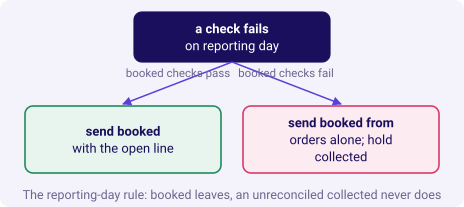

In [10]:
kit.tree({"label": "a check fails\non reporting day", "branches": [
    ("booked checks pass", {"label": "send booked\nwith the open line", "kind": "good"}),
    ("booked checks fail", {"label": "send booked from\norders alone; hold collected", "kind": "bad"}),
]}, taken=["booked checks pass"], title="The reporting-day rule: booked leaves, an unreconciled collected never does")

**What happened.** The answer is b. The team works to one rule: booked always leaves, because it ties
to the orders table alone; an unreconciled collected figure never leaves; and the open line, which
check failed, what it means and when it will be fixed, goes with it. Option c is the one people send,
and it puts an unreconciled figure on the CEO's page.

| The check that fails | What it means | What Anand gets that day | Who fixes it |
|---|---|---|---|
| Orders on the report against the table | The join dropped or repeated an order | Booked, and "collected held: the join lost or repeated orders" | You |
| Booked against orders alone | A fan-out that reached booked, or a dropped order | Booked from orders alone; collected held | You |
| The gap against booked less collected | A NULL fell out of a sum | The page, with the gap recomputed from the two columns | You |
| The gap against the never-paid and paid-short lists | A list or a bar is wrong | Booked and collected, the gap marked provisional | You, with Kavya |
| Collected plus posted twice against posted | The feed changed, or a retry arrived in a new shape | Booked; collected held; the platform lead told the same day | The platform lead |

In [11]:
owners = {"orders on the report equal orders in the table": "you", "booked equals booked from orders alone": "you",
          "the gap equals booked less collected": "you", "the gap equals the never-paid and paid-short lists": "you, with Kavya",
          "collected plus posted twice equals posted from payments alone": "the platform lead"}
kit.check("every tie-back check has a named owner for the day it fails", set(owners) == {n_ for n_, _ in TIE_BACK},
          f"{len(owners)} checks, {len(set(owners.values()))} owners")

### In the interview: what runs before a joined number reaches Finance, and which one check would you keep?

The tags mark how often a question comes up: [S] a staple asked everywhere, [F] frequent in GCC and product screens, [D] a differentiator.

**[D] Design the validation you run before a joined number reaches Finance, and say what you do when it fails at the end of reporting day.** The validation has four layers, each run every time. The counts come first: rows in against rows out, and orders on
the report against orders in the table, with the join key unique on its one side and the keys that
match nothing counted on the other. The tie-backs follow: booked recomputed from `orders` alone,
posted from `payments` alone, and each bar of the bridge equal to the total of its named list. The
third layer is one independent recomputation, in another tool from the raw rows, or against the
gateway's settlement file when there is one, after checking that the feed is complete up to the
quarter's cut-off. The last tests the suite itself: run it against the known wrong reports, the
fan-out, the dropped order, the NULL gap, and show that each fails. When a
check fails late on reporting day, send what is reconciled, booked, which ties to orders alone, with the open line
stated, which check failed, what it means and when it will close; hold the collected figure; and
tell the owner the same day. An unreconciled number never leaves with a PASS on it.

**[S] If you could keep only one check before a joined number leaves, which would you keep?** Keep orders on the report against orders in the source table. A join goes wrong in two ways, a
fan-out and a dropped order, and this check catches both without reading a rupee, in a millisecond.
It misses what goes wrong after the join: on the day's five wrong pages it stops three, and lets
through posted read as collected and the gap summed past a NULL, which is why the gap's tie-back to
the never-paid and paid-short lists is the second check added. That tie-back stops all five pages,
yet it comes second, because the lists are queries of their own that can carry the page's mistake (a
date in WHERE empties the page and the list together), while the count reads nothing but `orders`.

### Depth: why is a settlement file stronger than any check on Kalpa's own tables?

Every check in this suite reads Kalpa's own records, so a record that is wrong at the source, a
payment the feed invented or lost, passes all of them. A settlement file comes from the gateway and
the bank, outside Kalpa, and a difference between it and the payments table is evidence nobody at
Kalpa wrote. By the FT's account above, Wirecard's auditor relied on documents from Wirecard and its
trustee instead of checking directly with OCBC Bank.

## What did this chapter answer, one line per question?

1. Three plausibility checks pass the quarter-in-WHERE page that hides T-4, 3 of 3, because each
   tests the page against itself.
2. Five tie-back checks compare the page's orders, booked, gap and collected with figures computed
   outside it; on that page three of them fail.
3. The plausibility suite lets through two of the day's five wrong pages, the two that hide T-4; the
   tie-back suite stops all five and passes the true page.
4. On Kalpa's Q2 report every tie-back check passes: 462 orders against 462, Rs 9,84,00,000 against
   Rs 9,84,00,000, the gap tied to the never-paid and paid-short lists, the retries to posted.
5. Python, counting the raw rows with no join, reaches the same orders, booked, collected and gap, on
   the invented tables and on Kalpa's Q2.
6. When a check fails at the end of reporting day, Anand gets booked with the open line named, the
   collected figure is held, and the check's owner hears the same day.

**The day's answer, for Anand.** Q2 booked Rs 9,84,00,000; collected, each payment counted once, is
the figure on your own page; the gap is the orders nobody paid, named by channel; the retries and
the payments with no order go to the platform lead; and every figure ties back to the orders and
payments tables through checks that have each been seen to fail.

In [12]:
kit.check_summary()